In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, precision_score

In [2]:
loan_df = pd.read_csv("loan_approval_data.csv")
loan_df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
loan_df.isnull().sum()
loan_df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handle Missing Value

In [5]:
cat_cols = loan_df.select_dtypes(include=["object"]).columns
num_cols = loan_df.select_dtypes(include=["number"]).columns

In [6]:
cat_cols
num_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [7]:
num_imp = SimpleImputer(strategy="mean")
loan_df[num_cols] = num_imp.fit_transform(loan_df[num_cols])

In [8]:
loan_df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [9]:
cat_imp = SimpleImputer(strategy="most_frequent")
loan_df[cat_cols] = cat_imp.fit_transform(loan_df[cat_cols])

In [10]:
loan_df.head()
loan_df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

Text(0.5, 1.0, 'Is loan approved or not?')

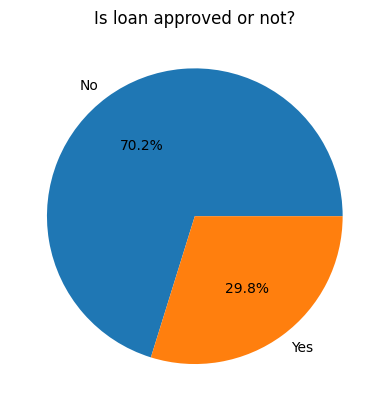

In [11]:
# how balanced our classes are? 

classes_count = loan_df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is loan approved or not?")

[Text(0, 0, '621'), Text(0, 0, '379')]

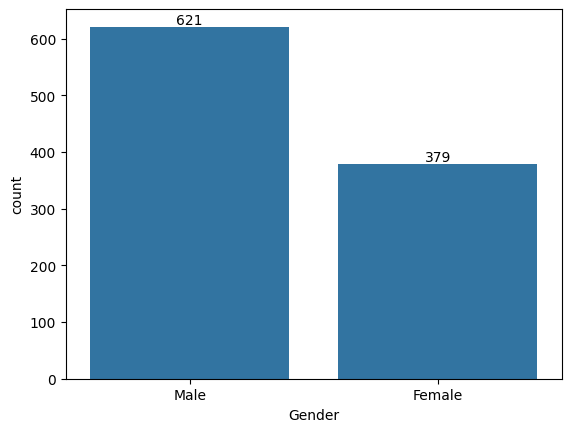

In [12]:
# analyze categorieds

gender_cnt = loan_df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

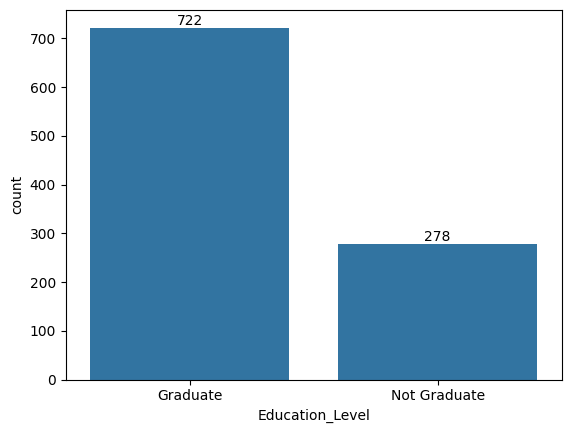

In [13]:
edu_cnt = loan_df["Education_Level"].value_counts()
bx = sns.barplot(edu_cnt)
bx.bar_label(bx.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

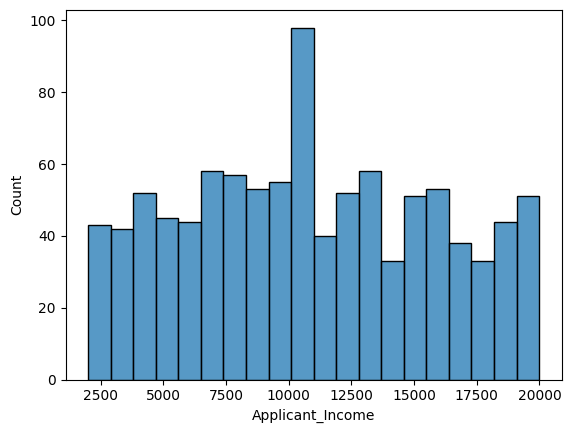

In [14]:
# analyze income

sns.histplot(
    data = loan_df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

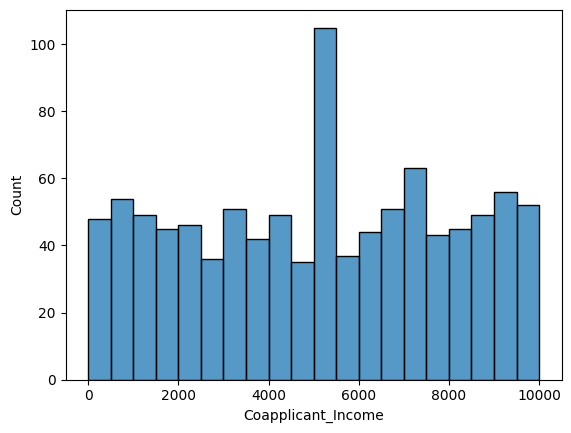

In [15]:
sns.histplot(
    data = loan_df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

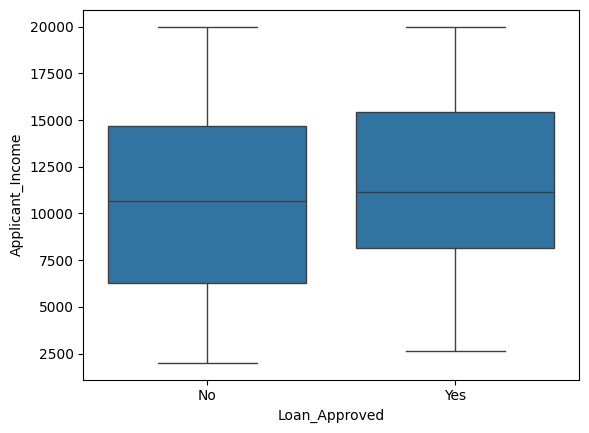

In [16]:
# outlier - box plots

sns.boxplot(
    data=loan_df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

<Axes: xlabel='Loan_Approved', ylabel='Age'>

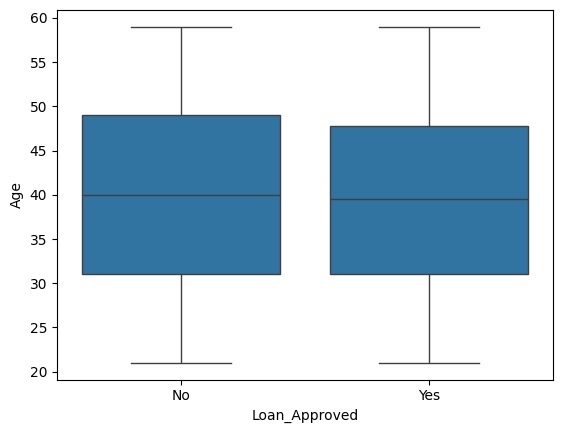

In [17]:
sns.boxplot(
    data=loan_df,
    x = "Loan_Approved",
    y = "Age"
)

<Axes: xlabel='Loan_Approved', ylabel='Loan_Amount'>

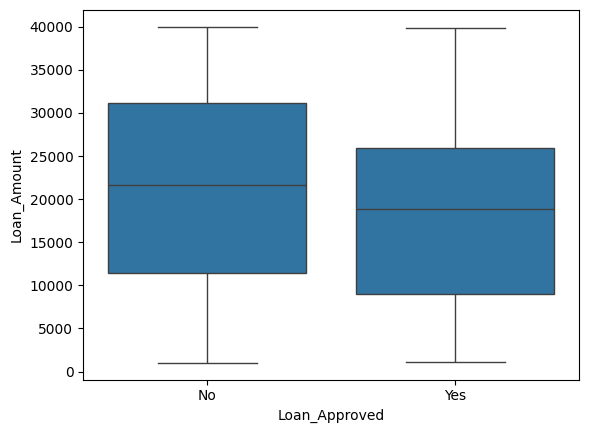

In [18]:
sns.boxplot(
    data=loan_df,
    x = "Loan_Approved",
    y = "Loan_Amount"
)

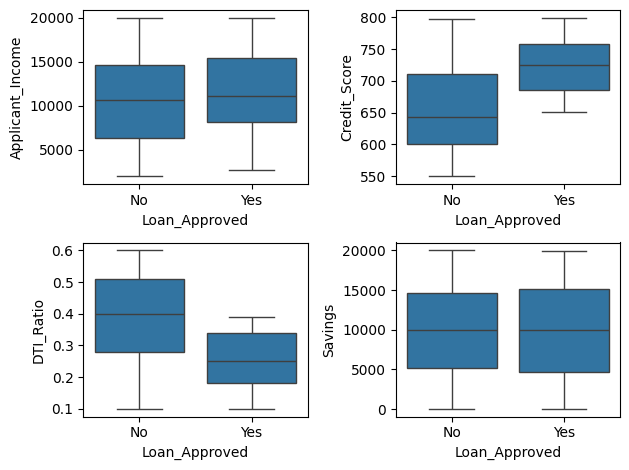

In [19]:
fig, axes = plt.subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=loan_df, x = "Loan_Approved",
    y = "Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=loan_df, x = "Loan_Approved",
    y = "Credit_Score")
sns.boxplot(ax=axes[1, 0], data=loan_df, x = "Loan_Approved",
    y = "DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data=loan_df, x = "Loan_Approved",
    y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

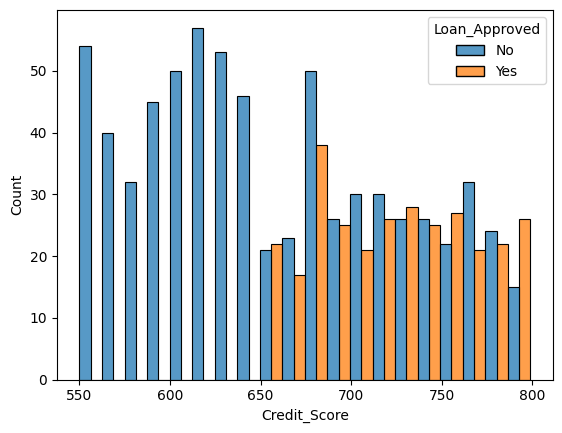

In [20]:
# credit Score with Loan Approved

sns.histplot(
    data = loan_df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

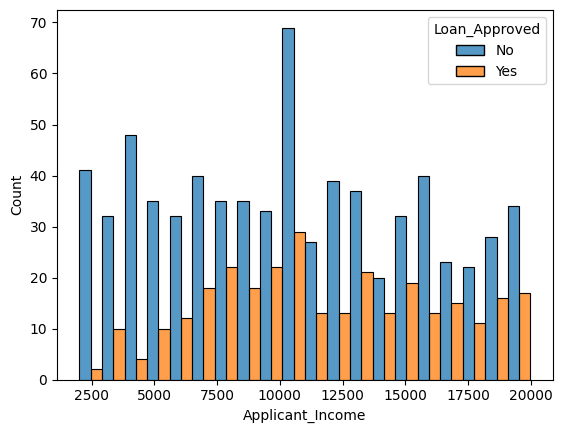

In [21]:
sns.histplot(
    data = loan_df,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [22]:
# remove applicant Id
loan_df = loan_df.drop("Applicant_ID", axis=1)

In [23]:
loan_df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
loan_df["Education_Level"] = le.fit_transform(loan_df["Education_Level"])
loan_df["Loan_Approved"] = le.fit_transform(loan_df["Loan_Approved"])

In [25]:
loan_df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [50]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(loan_df[cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=loan_df.index)


In [51]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatma

In [52]:
num_cols = loan_df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

In [53]:
num_cols.corr()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Loan_Approved
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,-0.033258,-0.014593,0.119796
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,0.005894,-0.022918,0.004230
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,-0.027636,0.025020,-0.022343
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,-0.006231,-0.023493,-0.023811
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,-0.054224,0.005367,0.451175
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,0.066126,-0.008208,-0.034794
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,0.030006,0.010084,-0.444783
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,0.018644,-0.038536,-0.013437
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,0.039503,0.013921,0.021868
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,-0.000303,-0.011424,-0.126499


In [54]:
corr_matrix["Education_Level"].sort_values(ascending=False)

Education_Level       1.000000
Age                   0.025020
Collateral_Value      0.013921
DTI_Ratio             0.010084
Credit_Score          0.005367
Existing_Loans       -0.008208
Loan_Amount          -0.011424
Applicant_Income     -0.014593
Loan_Term            -0.020413
Coapplicant_Income   -0.022918
Dependents           -0.023493
Savings              -0.038536
Loan_Approved        -0.052920
Name: Education_Level, dtype: float64

<Axes: >

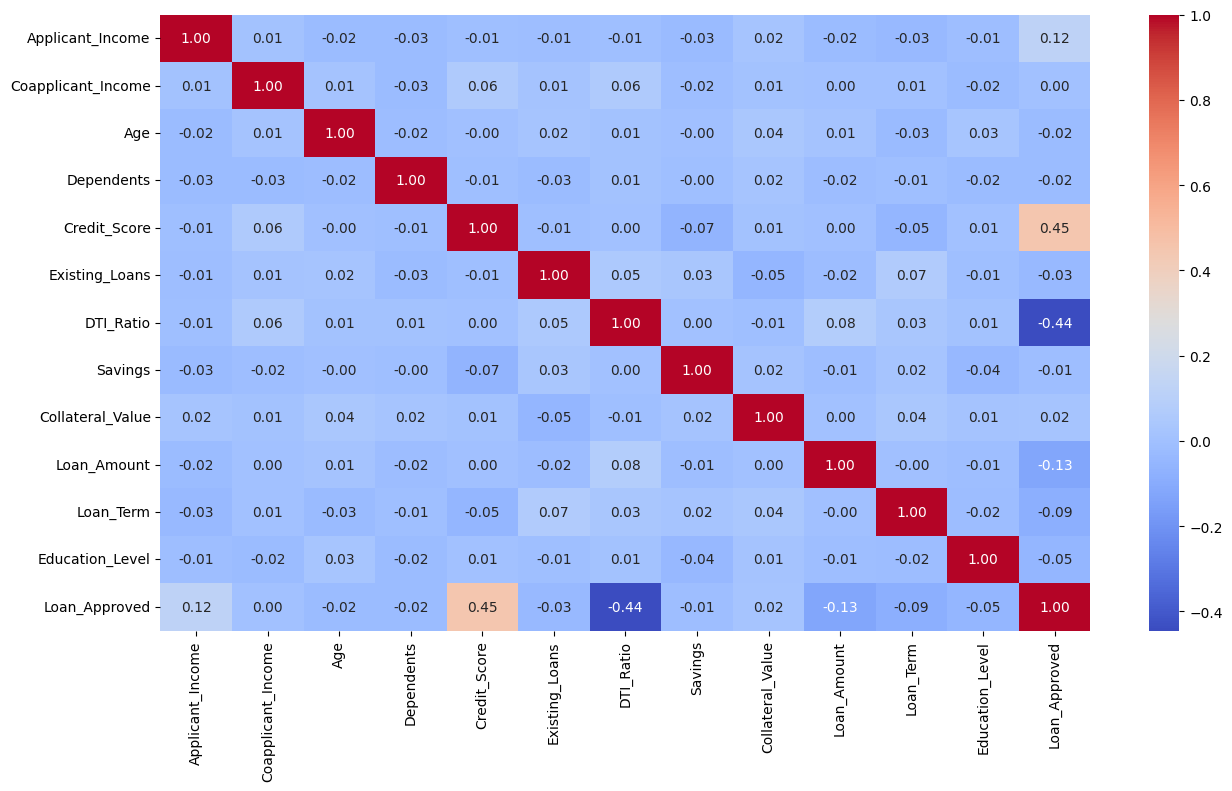

In [55]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap = "coolwarm"
)

In [66]:
X = loan_df.drop(["Loan_Approved"], axis=1)
y = loan_df["Loan_Approved"]
X = pd.get_dummies(X, drop_first=True)


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [68]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,False,False,False,False,False,False,True,False,False,False
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,False,True,False,False,True,True,False,False,False,False
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,False,False,True,True,False,True,False,False,True,False
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,False,True,False,False,True,False,True,False,False,False
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,False,True,False,False,True,False,False,False,True,False


In [69]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

# Training and Evaluation

In [81]:
# LogisticRegression
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Precision Score", precision_score(y_test, y_pred))
print("F1_score", f1_score(y_test, y_pred))
print("Accuracy Score", accuracy_score(y_test, y_pred))
print("reacall Score", recall_score(y_test, y_pred))
print("cm", confusion_matrix(y_test, y_pred))

Precision Score 0.7833333333333333
F1_score 0.7768595041322314
Accuracy Score 0.865
reacall Score 0.7704918032786885
cm [[126  13]
 [ 14  47]]


In [100]:
# knn
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=21)

knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)
print("Precision Score", precision_score(y_test, y_pred))
print("F1_score", f1_score(y_test, y_pred))
print("Accuracy Score", accuracy_score(y_test, y_pred))
print("reacall Score", recall_score(y_test, y_pred))
print("cm", confusion_matrix(y_test, y_pred))

Precision Score 0.8214285714285714
F1_score 0.5168539325842697
Accuracy Score 0.785
reacall Score 0.3770491803278688
cm [[134   5]
 [ 38  23]]


In [102]:
# naive bayes
from sklearn.naive_bayes import GaussianNB

nab_model = GaussianNB()

nab_model.fit(X_train_scaled, y_train)
y_pred = nab_model.predict(X_test_scaled)
print("Precision Score", precision_score(y_test, y_pred))
print("F1_score", f1_score(y_test, y_pred))
print("Accuracy Score", accuracy_score(y_test, y_pred))
print("reacall Score", recall_score(y_test, y_pred))
print("cm", confusion_matrix(y_test, y_pred))

Precision Score 0.8035714285714286
F1_score 0.7692307692307693
Accuracy Score 0.865
reacall Score 0.7377049180327869
cm [[128  11]
 [ 16  45]]


In [103]:
# Add or transfrom feature
loan_df["DTI_Ratio_sq"] = loan_df["DTI_Ratio"] ** 2
loan_df["Credit_Score_sq"] = loan_df["Credit_Score"] ** 2

X = loan_df.drop(columns=["Loan_Approved", "DTI_Ratio", "Credit_Score"])
y = loan_df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [104]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,False,False,False,False,True,False,False,False,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,False,False,True,True,False,False,False,False,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,True,True,False,True,False,False,True,False,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,False,False,True,False,True,False,False,False,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,False,False,True,False,False,False,True,False,0.0324,457021.542187


In [105]:
# Scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
# LogisticRegression
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Precision Score", precision_score(y_test, y_pred))
print("F1_score", f1_score(y_test, y_pred))
print("Accuracy Score", accuracy_score(y_test, y_pred))
print("reacall Score", recall_score(y_test, y_pred))
print("cm", confusion_matrix(y_test, y_pred))

Precision Score 0.7903225806451613
F1_score 0.7967479674796748
Accuracy Score 0.875
reacall Score 0.8032786885245902
cm [[126  13]
 [ 12  49]]


In [112]:
# knn
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=11)

knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)
print("Precision Score", precision_score(y_test, y_pred))
print("F1_score", f1_score(y_test, y_pred))
print("Accuracy Score", accuracy_score(y_test, y_pred))
print("reacall Score", recall_score(y_test, y_pred))
print("cm", confusion_matrix(y_test, y_pred))

Precision Score 0.7560975609756098
F1_score 0.6078431372549019
Accuracy Score 0.8
reacall Score 0.5081967213114754
cm [[129  10]
 [ 30  31]]


In [113]:
# naive bayes
from sklearn.naive_bayes import GaussianNB

nab_model = GaussianNB()

nab_model.fit(X_train_scaled, y_train)
y_pred = nab_model.predict(X_test_scaled)
print("Precision Score", precision_score(y_test, y_pred))
print("F1_score", f1_score(y_test, y_pred))
print("Accuracy Score", accuracy_score(y_test, y_pred))
print("reacall Score", recall_score(y_test, y_pred))
print("cm", confusion_matrix(y_test, y_pred))

Precision Score 0.7833333333333333
F1_score 0.7768595041322314
Accuracy Score 0.865
reacall Score 0.7704918032786885
cm [[126  13]
 [ 14  47]]
